# Notebook 12 — KymoRoPE: modelo por-pixel a resolución nativa

Implementación de `plan/kymorope-guide.md`. **Este notebook construye y verifica el modelo; no
corre el entrenamiento completo** — §7 está definido y desactivado por bandera, y §7.1 hace una
corrida mínima de verificación (que sí entrena, a una escala que no produce un modelo).

## Qué se verifica acá, y por qué cada cosa

La guía hace tres afirmaciones de diseño que se pueden romper en silencio. Cada sección
las convierte en una aserción:

| §         | afirmación de la guía                                         | se verifica en                       |
| --------- | ------------------------------------------------------------- | ------------------------------------ |
| §2.2      | la RoPE codifica **separación física**, no índices de píxel   | §2, cuatro aserciones                |
| §2.3      | el empaquetado no mezcla muestras                             | §6, aislamiento con control negativo |
| §2.1/§2.4 | nada se redimensiona y la salida vuelve a resolución completa | §3.1, extremos 48×99 y 463×2722      |

Más lo que hace falta para que un entrenamiento no se caiga a la mitad: gradientes por los tres
heads (§4) y el costo real en memoria de MPS con y sin _checkpointing_ (§5).

**Dispositivo**: Apple Silicon / MPS. `PYTORCH_ENABLE_MPS_FALLBACK=1` va **antes** de
`import torch` (mismo patrón que `scripts/entrenar_atencion_v1.py`), todo en float32 — MPS no
soporta float64.


---

## 0. Setup


In [1]:
import gc
import os
import sys
import time
import types
import warnings
from pathlib import Path

os.environ.setdefault("PYTORCH_ENABLE_MPS_FALLBACK", "1")  # ANTES de importar torch

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import tifffile
import torch

RAIZ = Path("..").resolve()
sys.path.append(str(RAIZ / "src"))
warnings.filterwarnings("ignore", message=".*requires_grad.*")

from axonal_tracking import datos_pixel as dp
from axonal_tracking import kymorope as kr

DISPOSITIVO = kr.dispositivo_preferido()
print("dispositivo:", DISPOSITIVO)
for k, v in kr.resumen_mps().items():
    print(f"  {k:12s} {v}")

dispositivo: mps
  disponible   True
  compilado    True
  torch        2.12.0
  asignado_mb  0.0
  driver_mb    0.5


---

## 1. Targets por-píxel (§3 de la guía)

Los tres targets salen de `positions.csv` a través de **las mismas funciones que exportan las
etiquetas de los otros pipelines** (`mascara_traza` / `ids_que_se_mueven`), espejo L-R incluido.
No hay un segundo rasterizador: duplicarlo es como se reintroduce el bug que la docstring de
`mascara_traza(dilatar=False)` documenta.

La decisión abierta de §3 queda **cerrada acá como opción 1**: los píxeles reclamados por ≥2
partículas se excluyen del término de atracción (`mask_pull`) y de la pérdida de orientación
(`mask_theta`). Promediar dos identidades en un cruce es exactamente el modo de falla que el
head de embedding existe para evitar.


In [2]:
MUESTRA = "sample_00099"  # 5 móviles, 4 de ellas se cruzan
d = RAIZ / "datasets" / "test" / MUESTRA

kymo_crudo = tifffile.imread(d / "kymograph.tif")
positions = pd.read_csv(d / "positions.csv")
tg = dp.construir_targets(positions, kymo_crudo.shape)

clases, cuentas = np.unique(tg.trackness, return_counts=True)
frac = cuentas / cuentas.sum()
print(f"{MUESTRA}: T={kymo_crudo.shape[0]}  L={kymo_crudo.shape[1]}")
print(
    f"  trackness  fondo {frac[0]:.3f} | estatica {frac[1]:.3f} | movil {frac[2]:.3f}"
)
print(f"  instancias moviles: {tg.n_instancias}")
es_traza = tg.trackness > 0
print(
    f"  supervision: theta sobre {tg.mask_theta.sum() / es_traza.sum():.1%} de los px de traza"
)
print(
    f"               pull  sobre {tg.mask_pull.sum() / (tg.trackness == 2).sum():.1%} de los px moviles"
)
print(
    "  -> el resto son px reclamados por >=2 particulas, excluidos a proposito (opcion 1)"
)
print(
    f"  norma de theta: {np.linalg.norm(tg.theta, axis=-1).min():.4f} .. "
    f"{np.linalg.norm(tg.theta, axis=-1).max():.4f}  (debe ser 1)"
)

sample_00099: T=186  L=902
  trackness  fondo 0.836 | estatica 0.123 | movil 0.041
  instancias moviles: 5
  supervision: theta sobre 84.0% de los px de traza
               pull  sobre 81.0% de los px moviles
  -> el resto son px reclamados por >=2 particulas, excluidos a proposito (opcion 1)
  norma de theta: 1.0000 .. 1.0000  (debe ser 1)


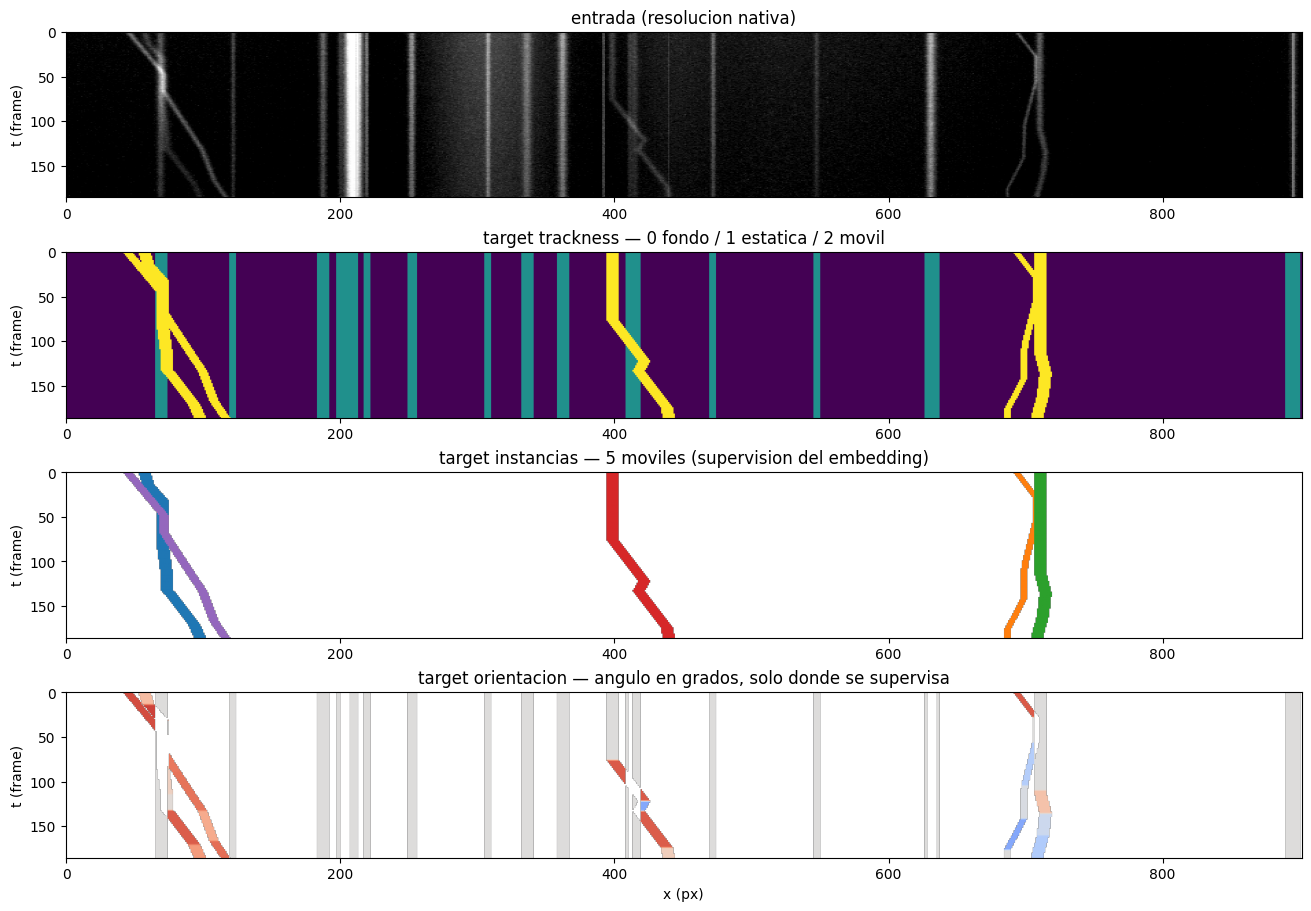

In [3]:
# Los tres targets, como los ve la perdida
fig, axs = plt.subplots(4, 1, figsize=(13, 9), constrained_layout=True)
lo, hi = np.percentile(kymo_crudo, [50, 99.8])
axs[0].imshow(kymo_crudo, cmap="gray", vmin=lo, vmax=hi, aspect="auto")
axs[0].set_title("entrada (resolucion nativa)")
axs[1].imshow(tg.trackness, cmap="viridis", vmin=0, vmax=2, aspect="auto")
axs[1].set_title("target trackness — 0 fondo / 1 estatica / 2 movil")
axs[2].imshow(
    np.where(tg.instancias > 0, tg.instancias, np.nan),
    cmap="tab10",
    vmin=1,
    vmax=10,
    aspect="auto",
)
axs[2].set_title(
    f"target instancias — {tg.n_instancias} moviles (supervision del embedding)"
)
ang = np.degrees(np.arctan2(tg.theta[..., 0], tg.theta[..., 1]))
axs[3].imshow(
    np.where(tg.mask_theta, ang, np.nan),
    cmap="coolwarm",
    vmin=-35,
    vmax=35,
    aspect="auto",
)
axs[3].set_title("target orientacion — angulo en grados, solo donde se supervisa")
for ax in axs:
    ax.set_ylabel("t (frame)")
axs[3].set_xlabel("x (px)")
plt.show()

---

## 2. La RoPE física (§2.2) — cuatro aserciones

La afirmación de la guía es que la codificación depende de la **separación física** entre dos
tokens (Δt en segundos, Δx en µm), no de su separación en índices. Si eso no se cumple, la
invariancia a la tasa de muestreo de §5.3 es decorativa y el resto del argumento se cae.

1. **Relativa**: trasladar ambos tokens no cambia el producto q·k.
2. **Invariancia de fps**: la misma Δt física obtenida desde dos fps distintos da el mismo
   producto. Fila 1 a 3.29 fps ≡ fila 1.5745 a 5.18 fps.
3. **Control negativo**: si las frecuencias ignoraran `dt`, (2) daría 0 por construcción. Se
   comprueba que _no_ dar el mismo Δt sí cambia el producto.
4. **Cableado**: `dt` llega efectivamente al modelo completo, no sólo al módulo.


In [4]:
torch.manual_seed(0)
rope = kr.RoPE2DFisica(64).to(DISPOSITIVO)


def producto(t_seg, x_um, q, k):
    cos, sin = rope(
        torch.tensor(t_seg, device=DISPOSITIVO), torch.tensor(x_um, device=DISPOSITIVO)
    )
    return (
        kr.aplicar_rope(q, cos, sin) @ kr.aplicar_rope(k, cos, sin).transpose(-1, -2)
    ).squeeze()


q = torch.randn(1, 1, 2, 64, device=DISPOSITIVO)
k = torch.randn(1, 1, 2, 64, device=DISPOSITIVO)

# (1) relativa
A = producto([0.0, 1.2], [0.0, 3.5], q, k)
B = producto([7.3, 8.5], [11.0, 14.5], q, k)
e1 = float((A - B).abs().max())

# (2) invariancia de fps: misma separacion FISICA, dos tasas de muestreo del dataset
dt_lento, dt_rapido = 1 / 3.29, 1 / 5.18
fila_equiv = dt_lento / dt_rapido
C = producto([0.0, dt_lento * 1], [0.0, 0.0], q, k)
D = producto([0.0, dt_rapido * fila_equiv], [0.0, 0.0], q, k)
e2 = float((C - D).abs().max())

# (3) control negativo: una fila a 5.18 fps NO es la misma Dt fisica
E = producto([0.0, dt_rapido * 1], [0.0, 0.0], q, k)
e3 = float((C - E).abs().max())

print(f"(1) relativa            max|A-B| = {e1:.2e}   (~0)")
print(
    f"(2) invariancia de fps  max|C-D| = {e2:.2e}   (~0)  fila 1 @3.29fps == fila {fila_equiv:.4f} @5.18fps"
)
print(f"(3) control negativo    max|C-E| = {e3:.2e}   (>> 0)")
assert e1 < 1e-3, "la RoPE no es relativa"
assert e2 < 1e-4, "la RoPE no es invariante a la tasa de muestreo"
assert e3 > 1e-1, "control negativo: dt no esta cambiando nada"
print("\nOK: la codificacion depende de la separacion FISICA, no de indices.")

(1) relativa            max|A-B| = 1.29e-05   (~0)
(2) invariancia de fps  max|C-D| = 0.00e+00   (~0)  fila 1 @3.29fps == fila 1.5745 @5.18fps
(3) control negativo    max|C-E| = 2.30e+00   (>> 0)

OK: la codificacion depende de la separacion FISICA, no de indices.


In [5]:
# (4) dt llega al modelo completo, no solo al modulo
ds_mini = dp.DatasetKymografos(RAIZ / "datasets" / "test", limite=1)
mu = ds_mini[0]
mu_2x = types.SimpleNamespace(**{**mu.__dict__, "dt_segundos": mu.dt_segundos * 2})

modelo_test = kr.KymoRoPE(n_capas=2).to(DISPOSITIVO).eval()
with torch.no_grad():
    o1 = modelo_test([mu])[0].trackness
    o2 = modelo_test([mu_2x])[0].trackness
e4 = float((o1 - o2).abs().max())
print(f"(4) cableado  max|salida(dt) - salida(2*dt)| = {e4:.4f}   (> 0)")
assert e4 > 1e-4, "dt no llega al forward: la RoPE fisica no esta conectada"
print("OK: dt esta cableado de punta a punta.")
del modelo_test, o1, o2
gc.collect()
torch.mps.empty_cache()

(4) cableado  max|salida(dt) - salida(2*dt)| = 0.0131   (> 0)
OK: dt esta cableado de punta a punta.


---

## 3. El modelo (§2)


In [6]:
modelo = kr.KymoRoPE().to(DISPOSITIVO)
por_bloque = {}
for nombre, p in modelo.named_parameters():
    por_bloque[nombre.split(".")[0]] = (
        por_bloque.get(nombre.split(".")[0], 0) + p.numel()
    )
total = sum(por_bloque.values())
for nombre, n in sorted(por_bloque.items(), key=lambda t: -t[1]):
    print(f"  {nombre:18s} {n:>11,d}  ({100 * n / total:4.1f}%)")
print(f"  {'TOTAL':18s} {total:>11,d}  ({total / 1e6:.2f} M)")
print("\n  RoPE: 0 parametros (frecuencias fijas), sin PE aprendida, sin CLS")
print(
    f"  lambda_t = {kr.LAMBDA_MIN_T_S}..{kr.LAMBDA_MAX_T_S} s | "
    f"lambda_x = {kr.LAMBDA_MIN_X_UM}..{kr.LAMBDA_MAX_X_UM} um"
)

  bloques             21,293,568  (82.8%)
  stem                 3,814,528  (14.8%)
  decoder                594,528  ( 2.3%)
  ln_final                   768  ( 0.0%)
  head_embedding             520  ( 0.0%)
  head_trackness             195  ( 0.0%)
  head_orientacion           130  ( 0.0%)
  TOTAL               25,704,237  (25.70 M)

  RoPE: 0 parametros (frecuencias fijas), sin PE aprendida, sin CLS
  lambda_t = 0.4..320.0 s | lambda_x = 0.2..640.0 um


### 3.1 Formas extremas — nada se redimensiona

El dataset va de 48×99 a 463×2722 (~300× de rango en cantidad de tokens). El punto del diseño
es no redimensionar nunca, así que las dos puntas tienen que pasar tal cual.


In [7]:
def muestra_falsa(T, L, dt=0.304, dx=0.107, device=None):
    """(T, L) aleatorio con la interfaz que espera el modelo."""
    dev = device or DISPOSITIVO
    o = types.SimpleNamespace(nombre=f"{T}x{L}", dt_segundos=dt, dx_um=dx)
    o.kymo = torch.rand(1, T, L, device=dev)
    return o


modelo.eval()
print(f"{'forma':>12} {'tokens':>7} {'fwd s':>7} {'pico MB':>9}   salida")
for T, L in [(48, 99), (52, 1613), (218, 1316), (463, 2722)]:
    gc.collect()
    torch.mps.empty_cache()
    base = torch.mps.driver_allocated_memory()
    x = muestra_falsa(T, L)
    torch.mps.synchronize()
    t0 = time.time()
    with torch.no_grad():
        s = modelo([x])[0]
    torch.mps.synchronize()
    print(
        f"{T:5d}x{L:<6d} {dp.tokens_de_forma((T, L)):7d} {time.time() - t0:7.2f} "
        f"{(torch.mps.driver_allocated_memory() - base) / 1e6:9.0f}   {tuple(s.trackness.shape)}"
    )
    del x, s
gc.collect()
torch.mps.empty_cache()

       forma  tokens   fwd s   pico MB   salida
   48x99          21    0.09         9   (3, 48, 99)
   52x1613       404    0.10        76   (3, 52, 1613)
  218x1316      1162    0.12      1084   (3, 218, 1316)
  463x2722      4959    0.17      1166   (3, 463, 2722)


---

## 4. Pérdidas y gradientes (§2.5)

`L = λ₁·(CE+Dice) + λ₂·discriminativa + λ₃·coseno`. El desglose se mira por separado a
propósito: si el embedding colapsa mientras el trackness baja, el total no lo muestra.

El chequeo que importa: **ningún parámetro sin gradiente**. Un head desconectado entrena sin
error y da basura.


In [8]:
def a_dispositivo(m, device=None):
    """Mueve los tensores de una MuestraPixel al dispositivo."""
    dev = device or DISPOSITIVO
    campos = ["kymo", "trackness", "instancias", "theta", "mask_pull", "mask_theta"]
    return type(m)(**{**m.__dict__, **{c: getattr(m, c).to(dev) for c in campos}})


ds = dp.DatasetKymografos(RAIZ / "datasets" / "test", limite=4)
muestra = a_dispositivo(ds[0])

modelo.train()
salida = modelo([muestra])[0]
perdidas = kr.perdida_total(salida, muestra)
perdidas["total"].backward()

print("perdidas (modelo sin entrenar):")
for nombre, v in perdidas.items():
    print(f"  {nombre:12s} {float(v.detach()):.4f}")
sin_grad = [n for n, p in modelo.named_parameters() if p.grad is None]
no_finito = [
    n
    for n, p in modelo.named_parameters()
    if p.grad is not None and not torch.isfinite(p.grad).all()
]
print(f"\nparametros sin gradiente : {len(sin_grad)}   (debe ser 0)")
print(f"gradientes no finitos    : {len(no_finito)}   (debe ser 0)")
assert not sin_grad and not no_finito
print("\n|grad| por head:")
for n, p in modelo.named_parameters():
    if n.startswith("head_"):
        print(f"  {n:34s} {float(p.grad.norm()):.3e}")
modelo.zero_grad(set_to_none=True)
del salida, perdidas
gc.collect()
torch.mps.empty_cache()

perdidas (modelo sin entrenar):
  total        2.2665
  trackness    2.0594
  embedding    0.1519
  orientacion  0.1104

parametros sin gradiente : 0   (debe ser 0)
gradientes no finitos    : 0   (debe ser 0)

|grad| por head:
  head_trackness.weight              1.895e+00
  head_trackness.bias                6.238e-01
  head_embedding.weight              3.580e+00
  head_embedding.bias                8.625e-04
  head_orientacion.weight            1.260e+00
  head_orientacion.bias              4.313e-01


---

## 5. MPS: el _checkpointing_ no es opcional en la cola larga

Medición real de un paso completo (forward + backward + `AdamW.step`) con el modelo de 12 capas.
`usar_checkpoint=True` recalcula las activaciones de cada bloque en el backward en vez de
guardarlas.


In [9]:
def muestra_falsa_completa(T, L):
    o = muestra_falsa(T, L)
    o.trackness = torch.randint(0, 3, (T, L), device=DISPOSITIVO)
    o.instancias = torch.randint(0, 6, (T, L), device=DISPOSITIVO)
    o.theta = torch.nn.functional.normalize(
        torch.rand(2, T, L, device=DISPOSITIVO), dim=0
    )
    o.mask_pull = o.instancias > 0
    o.mask_theta = o.trackness > 0
    return o


# Se mide `current_allocated_memory` (suma de tensores VIVOS) justo despues del
# forward: eso es exactamente la memoria de activaciones que el checkpointing no
# guarda. El delta de `driver_allocated_memory` NO sirve para comparar dos configs
# en el mismo kernel -- el pool del asignador no se devuelve entre mediciones y la
# segunda config parece gratis.
print(f"{'forma':>12} {'checkpoint':>11} {'paso s':>7} {'activaciones MB':>16}")
filas_mem = []
for T, L in [(218, 1316), (463, 2722)]:
    for ck in (False, True):
        gc.collect()
        torch.mps.empty_cache()
        m = kr.KymoRoPE(usar_checkpoint=ck).to(DISPOSITIVO).train()
        opt = torch.optim.AdamW(m.parameters(), lr=1e-4)
        x = muestra_falsa_completa(T, L)
        torch.mps.synchronize()
        base = torch.mps.current_allocated_memory()
        t0 = time.time()
        perdida = kr.perdida_total(m([x])[0], x)["total"]
        torch.mps.synchronize()
        activaciones = (torch.mps.current_allocated_memory() - base) / 1e6
        perdida.backward()
        opt.step()
        opt.zero_grad(set_to_none=True)
        torch.mps.synchronize()
        dt_s = time.time() - t0
        filas_mem.append((f"{T}x{L}", ck, dt_s, activaciones))
        print(f"{T:5d}x{L:<6d} {ck!s:>11} {dt_s:7.2f} {activaciones:16.0f}")
        del m, opt, x, perdida
gc.collect()
torch.mps.empty_cache()

       forma  checkpoint  paso s  activaciones MB
  218x1316         False    0.57              484
  218x1316          True    0.16              358
  463x2722         False    0.57             2913
  463x2722          True    0.51             1617


**De dónde sale la memoria, medido**: no del decoder — de la **atención**.
`scaled_dot_product_attention` en MPS **materializa la matriz completa**: no hay kernel
fusionado, con máscara o sin ella. Medido a `B=3, H=6, N=2726`: **0.57 GB por capa**, × 12
capas ≈ 6.8 GB. Escala con `B · N_max²`, así que el lote peor del dataset manda.

Sobre ese peor lote real, paso completo:

| `max_tokens` | checkpoint | activaciones | s/paso | min/época |
| ------------ | ---------- | -----------: | -----: | --------: |
| 8192         | off        | **12.60 GB** |   2.07 |       5.1 |
| 8192         | **on**     |  **3.78 GB** |   2.38 |   **5.9** |
| 4096         | off        |      9.64 GB |   1.54 |       7.7 |
| 4096         | on         |      2.36 GB |   1.50 |       7.5 |

**3.3× menos memoria por 15 % de tiempo**, así que el checkpointing queda activado. Bajar
`max_tokens` acota `N_max` pero multiplica los pasos y sale más caro por época.

### El parche del stem — medido, y con una trampa

La atención va como `B · N²` y `N = píxeles / parche²`, así que subir el stem de stride 16 a 32
divide `N` por 4. **Pero el presupuesto de lote está en tokens y el stem/decoder cuestan por
píxel**: con el mismo `max_tokens`, el parche 32 mete ~2.7× más píxeles por lote y la memoria
**sube**. Medido sobre el peor lote real:

| parche | `max_tokens` |   B | N_max |  Mpx | activaciones |   s/paso | min/época |
| ------ | -----------: | --: | ----: | ---: | -----------: | -------: | --------: |
| 16     |         8192 |   3 |  2728 | 2.03 |      3.78 GB |     2.59 |       6.4 |
| 32     |         8192 |   8 |  1200 |    — | **10.31 GB** |     3.19 |       5.3 |
| **32** |     **2048** |   2 |  1008 | 1.98 |  **2.45 GB** | **0.83** |   **2.1** |

Con el presupuesto de **píxeles** igualado (2048 tokens a parche 32 ≈ 8192 a parche 16), el
parche 32 gana en las dos cosas: **35 % menos memoria y 3× más rápido**. Por eso
`kymorope.PARCHE = 32` y `entrenamiento.MAX_TOKENS_LOTE = 2048` se mueven juntos — si tocás uno
sin el otro, la memoria explota.

**Lo que esto cuesta y no está medido**: cada token cubre ahora 32×32 px en vez de 16×16, o sea
contexto más grueso en el encoder. La resolución de **salida** no cambia (el decoder sigue
recibiendo skips en s2/s4 y los heads suben a full-res), así que el riesgo es de granularidad de
contexto, no de precisión espacial. Si hace daño, lo dice el gate de §7 de la guía y no este
notebook. `KymoRoPE(parche=16)` vuelve al anterior.

**Advertencia operativa**: si interrumpís una celda en pleno `backward()` con checkpointing
activo, el hook de tensores guardados queda instalado en el kernel y **todo forward posterior
aborta** con `CheckpointError` (el contador de "tensores guardados en el forward" crece run a
run mientras el de recómputo queda fijo en el tamaño de un bloque). Única salida:
**Restart Kernel**.

Medición aparte, en procesos frescos (un `driver_allocated_memory` por config, sin pool
contaminado): el paso completo sobre 463×2722 pide **~17 GB sin checkpointing y ~5.6 GB con**.
Esa es la diferencia entre entrenar y no entrenar en una Mac de 16 GB.


---

## 6. Pipeline de datos (§2.3) — empaquetado sin padding

El stem corre por muestra (las convoluciones no se batchean con formas distintas) y los tokens
se apilan **paddeados** a `(B, N_max, d)` con una máscara de clave.

**Por qué padding y no una secuencia concatenada con máscara bloque-diagonal** (que es como
estaba): las dos son matemáticamente idénticas — las muestras nunca se atienden entre sí — pero
`scaled_dot_product_attention` calcula la matriz completa aunque la máscara después tape casi
todo. Concatenar B muestras de N tokens cuesta `(B·N)²` en vez de `B·N²`, o sea **B veces de
más**. Medido con 7 muestras de 1162 tokens: 1.10 s contra 0.23 s por pasada del encoder
(**4.8×**). Es el cambio que bajó la época de ~17 min a ~5.

El padding entra sólo como **clave** enmascarada; las filas de query padeadas se calculan igual
y se descartan al cortar. Así ninguna fila de la máscara queda toda en `False`, que es lo que
daría `NaN` en SDPA.

El bucketing agrupa por **conteo de tokens**, no por número de muestras. Con el lote paddeado el
costo es `B·N_max²`, así que además conviene que las muestras de un lote tengan tamaños
parecidos — por eso se ordena por costo antes de cortar.


In [10]:
ds_train = dp.DatasetKymografos(
    RAIZ / "datasets" / "train"
)  # las 800, para que los 5 fps aparezcan
formas = ds_train.formas()
lotes = dp.agrupar_por_tokens(formas, max_tokens=8192, max_muestras=8)
costos = [sum(dp.tokens_de_forma(formas[i]) for i in lote) for lote in lotes]
tam = [len(lote) for lote in lotes]
print(f"{len(formas)} muestras -> {len(lotes)} lotes")
print(
    f"  tokens por lote : min {min(costos)}  mediana {int(np.median(costos))}  max {max(costos)}  (tope 8192)"
)
print(
    f"  muestras por lote: min {min(tam)}  mediana {int(np.median(tam))}  max {max(tam)}"
)
print(f"  fps presentes   : {sorted(set(ds_train.fps()))}")

800 muestras -> 149 lotes
  tokens por lote : min 875  mediana 6977  max 8181  (tope 8192)
  muestras por lote: min 1  mediana 5  max 8
  fps presentes   : [3.29, 3.5, 4.0, 4.83, 5.18]


In [11]:
# Aislamiento del lote paddeado, con control negativo: sin mascara de clave, el
# padding de las otras muestras entra a la atencion y contamina el resultado.
modelo.eval()
a, b = ds[0], ds[1]
original = kr.AtencionRoPE.forward


def _sin_mascara(self, x, cos, sin, mascara):
    return original(self, x, cos, sin, None)


with torch.no_grad():
    sola = modelo([a])[0].trackness
    en_lote = modelo([a, b])[0].trackness
    try:
        kr.AtencionRoPE.forward = _sin_mascara
        fugado = modelo([a, b])[0].trackness
    finally:
        kr.AtencionRoPE.forward = original

aislado = float((sola - en_lote).abs().max())
fuga = float((sola - fugado).abs().max())
print(
    f"formas del lote: {[tuple(x.kymo.shape[-2:]) for x in (a, b)]}  -> hay padding real"
)
print(f"con mascara de clave  : max|sola - en lote| = {aislado:.2e}   (~0)")
print(f"sin mascara (control) : max|sola - en lote| = {fuga:.2e}   (>> 0)")
assert aislado < 1e-4 and fuga > 1e-4
print("\nOK: el padding no contamina a las otras muestras del lote.")
del sola, en_lote, fugado
gc.collect()
torch.mps.empty_cache()

formas del lote: [(170, 979), (162, 1598)]  -> hay padding real
con mascara de clave  : max|sola - en lote| = 1.67e-06   (~0)
sin mascara (control) : max|sola - en lote| = 3.21e-01   (>> 0)

OK: el padding no contamina a las otras muestras del lote.


---

## 7. Entrenamiento — `Trainer.train_model_v2`, no un bucle propio

El bucle escrito a mano se reemplazó por `notebooks/trainer.py::Trainer.train_model_v2` (AMP,
acumulación de gradiente, clipping, checkpointing, scheduler en el borde de acumulación, tqdm).
`src/axonal_tracking/entrenamiento.py` lo adapta sobreescribiendo **sólo** `compute_loss` /
`compute_eval_loss`, que es el único punto donde KymoRoPE no encaja con la clase base:

| `Trainer` asume          | KymoRoPE entrega                                                   |
| ------------------------ | ------------------------------------------------------------------ |
| `(input, target)` densos | `LoteEmpaquetado` — muestras de tamaño distinto, sin apilar (§2.3) |
| `model(x) -> tensor`     | `model(lista) -> lista de SalidaKymoRoPE`, 3 heads                 |
| `loss_fn(out, target)`   | `perdida_total(salida, muestra) -> dict` con desglose              |

### Dos correcciones en `trainer.py`

Afectan a cualquiera que use la clase, no sólo a este modelo:

1. **Escalado de gradiente con bf16 (bug real).** `train_model_v2` hacía
   `scaler.scale(loss).backward()` cuando `dtype` era `float16` **o** `bfloat16`, pero después
   sólo llamaba `scaler.step()` en el caso `float16`. Con bf16 los gradientes llegaban al
   optimizador multiplicados por el factor de escala (65536 por defecto) y sin desescalar. El
   `clip_grad_norm_(…, 1.0)` lo tapaba — renormalizaba todo a norma 1.0 en cada paso, con lo
   que la acumulación dejaba de significar nada. Ahora el scaler se habilita **sólo** en fp16
   (bf16 tiene el mismo rango de exponente que fp32 y no lo necesita) y el camino escalado usa
   siempre `scaler.step()`.
2. **`torch.cuda.empty_cache()` al final.** Sin CUDA es un no-op silencioso: en MPS no liberaba
   nada. Ahora vacía la caché del backend que corresponda.

También `save_checkpoint` guardaba `scaler_state_dict` sólo si `hasattr(self, "scaler")`, y
`train_model_v2` creaba el scaler como variable **local** — o sea, nunca se guardaba.

### Una que se dejó como estaba, señalada

`clip_grad_norm_` corre en **cada micro-batch**, no una vez antes del `optimizer.step()`. Eso
renormaliza progresivamente las acumulaciones parciales, que no es lo habitual. Cambiarlo altera
la dinámica de entrenamiento de cualquiera que ya use la clase, así que queda como está con un
comentario. Vale la pena decidirlo explícitamente.

### Parada temprana — deliberadamente sin cablear

`eval_model()` devuelve **pérdida de píxel**. §7 de la guía y `plan/decnet-finetune-guide.md`
piden parar por `frac_id_switch` a nivel trayectoria, y las dos métricas no se mueven juntas.
`entrenamiento.metrica_parada_temprana()` levanta `NotImplementedError` hasta que exista la
decodificación de §2.6: un `EarlyStopping` mal cableado es peor que ninguno, porque parece que
funciona.


In [12]:
EJECUTAR_ENTRENAMIENTO = True  # <- ponelo en True cuando §8 de la guia este cerrado

from axonal_tracking import entrenamiento as ent


def entrenar(
    epocas=40,
    fps_excluido=None,
    use_amp=True,
    dtype=torch.bfloat16,
    usar_checkpoint=True,
    **kw,
):
    """Entrenamiento completo via `Trainer.train_model_v2`. Devuelve (entrenador, historia).

    `fps_excluido` es el ablation de §5.3: saca una tasa de muestreo del train y la
    deja en val/test. Es un filtro sobre el Dataset, sin regenerar nada.

    Defaults elegidos por medicion. Paso completo, medido DENTRO de un kernel de
    Jupyter sobre lotes reales del dataset:

        cambio                                  s/lote   min/epoca (149 lotes)
        punto de partida (reportado)                --        ~17
        lote paddeado en vez de concatenado (SS6)  2.31        5.7
        + DataLoader con workers                   1.69        4.2   <- este

    Dentro del paso, AMP aporta ~8% y apagar el checkpointing ~15%; el resto vino de
    los dos cambios estructurales:

    1. **Atencion.** Concatenar B muestras en una secuencia con mascara
       bloque-diagonal cuesta `(B*N)^2` porque SDPA calcula la matriz completa
       aunque la mascara tape casi todo. El lote paddeado cuesta `B*N_max^2` (SS6).
    2. **Carga de datos.** Construir los targets cuesta ~63 ms de CPU por muestra y
       son DETERMINISTAS: rehacerlos cada epoca era trabajo puro al pedo (800 x 40 =
       ~34 min de CPU). `construir_entrenador` los cachea en disco y `__getitem__`
       baja a 0.7 ms (86x). Con eso la GPU deja de esperar y no hacen falta workers.
    3. **Parche del stem 16 -> 32** con `max_tokens` bajado en la misma proporcion.

    **La primera epoca es lenta y no esta rota**: MPS compila kernels por forma, y
    hay una forma distinta por lote. Medido: epoca 0 a 3.59 s/lote, epoca 1 a 0.60.

    **Memoria**: `usar_checkpoint=True` NO es opcional a este tamano. SDPA en MPS
    materializa la matriz de atencion completa (no hay kernel fusionado): 0.57 GB por
    capa a `B=3, H=6, N=2726`, x12 capas. Con los defaults actuales (parche 32,
    `max_tokens=2048`, checkpointing) el peor lote real pide **2.45 GB** y el paso
    tarda **0.83 s**.

    `max_tokens` esta atado a `kymorope.PARCHE`: el tope cuenta TOKENS pero el stem y
    el decoder cuestan por PIXEL. Subir el parche sin bajar el tope mete mas pixeles
    por lote y la memoria SUBE (10.31 GB medidos con parche 32 y 8192 tokens).

    **Cuidado**: con checkpointing, interrumpir una celda en pleno `backward()` deja
    el hook de tensores guardados instalado y todo forward posterior aborta con
    `CheckpointError`. Unica salida: **Restart Kernel**.
    """
    entrenador, info = ent.construir_entrenador(
        RAIZ / "datasets",
        epocas=epocas,
        fps_excluido=fps_excluido,
        usar_checkpoint=usar_checkpoint,
        **kw,
    )
    for k, v in info.items():
        print(f"  {k:28s} {v}")

    historia = []
    for epoca in range(epocas):
        perdida_train = entrenador.train_model_v2(use_amp=use_amp, dtype=dtype)
        desglose = entrenador.desglose_medio()
        val_pixel = (
            entrenador.eval_model()
        )  # PIXEL: NO es criterio de parada (ver arriba)
        historia.append(
            {"epoca": epoca, "train": perdida_train, "val_pixel": val_pixel, **desglose}
        )
        print(
            f"epoca {epoca:3d}  train {perdida_train:.4f}  val_pixel {val_pixel:.4f}  "
            + "  ".join(f"{k} {v:.4f}" for k, v in desglose.items())
        )
        # TODO(§2.6): decodificar val -> polilineas -> evaluar_trayectorias_polilineas
        #             y recien ahi `EarlyStopping` sobre frac_id_switch.
    return entrenador, historia


if EJECUTAR_ENTRENAMIENTO:
    entrenador, historia = entrenar()
else:
    print("entrenamiento completo NO ejecutado (EJECUTAR_ENTRENAMIENTO = False).")
    print("El smoke test de abajo corre el MISMO camino a escala minima.")

  dispositivo                  mps
  n_train                      800
  n_val                        400
  fps_train                    [3.29, 3.5, 4.0, 4.83, 5.18]
  fps_excluido                 None
  lotes_por_epoca              153
  pasos_optimizador_por_epoca  77
  total_steps_scheduler        3080
  scheduler                    OneCycleLR
  usar_checkpoint              True
  num_workers                  0
  cache_dir                    /Users/alejandrovalle/Desktop/Posgrado/CEIA/axonal-tracking/results/kymorope/cache
  parametros                   25704237


loss 3.77419:  65%|██████▍   | 99/153 [13:28<07:21,  8.17s/it]


KeyboardInterrupt: 

### 7.1 Smoke test — el mismo camino, 2 épocas sobre 16 muestras

**Esto sí entrena.** Son pasos de optimizador reales sobre datos reales y los pesos cambian. Lo
que no es, es _la_ corrida:

|                      |                         smoke |       `entrenar()` por defecto |
| -------------------- | ----------------------------: | -----------------------------: |
| muestras de train    |                            16 |                            800 |
| épocas               |                             2 |                             40 |
| pasos de optimizador |                            ~8 |                         ~3.000 |
| destino de los pesos | directorio temporal, se borra | `results/kymorope/checkpoints` |

Además el `OneCycleLR` está dimensionado para estas dos épocas, así que ni el schedule se parece
al de una corrida real. Sirve para una sola cosa: comprobar que el camino completo (bucketing →
collate empaquetado → `compute_loss` → backward → `step` → checkpoint) corre y que la pérdida
baja. Es el **mismo** `train_model_v2` / `eval_model` que usa `entrenar` — verificar un código
distinto del que después corre es como se pudre la garantía del notebook.

El `max_tokens` se baja a propósito para que salgan varios lotes por época y se ejerciten el
borde de acumulación y el `step` final desalineado.

**Ya no hacen falta workers.** Los targets se cachean en disco (`results/kymorope/cache/`), así
que `__getitem__` pasó de ~63 ms a **0.7 ms** por muestra (86×) y la carga de datos dejó de ser
el cuello de botella. Sin procesos extra: sin multiplicar memoria y sin la fragilidad de
`fork`/`spawn` dentro de un kernel de Jupyter, que llegó a colgarlo.


In [ ]:
import tempfile

gc.collect()
torch.mps.empty_cache()
with tempfile.TemporaryDirectory() as tmp:
    ent_smoke, info_smoke = ent.construir_entrenador(
        RAIZ / "datasets",
        epocas=2,
        limite_train=16,
        limite_val=4,
        gradient_accumulation_steps=2,
        max_tokens=800,
        save_dir=tmp,  # ~240 tok/muestra a parche 32
        usar_checkpoint=True,  # mismos defaults que `entrenar`
        num_workers=0,  # ver nota abajo: en el kernel del notebook, no
    )
    print(
        f"  lotes/epoca {info_smoke['lotes_por_epoca']}  "
        f"pasos de optimizador/epoca {info_smoke['pasos_optimizador_por_epoca']}  "
        f"checkpoint {info_smoke['usar_checkpoint']}"
    )
    for epoca in range(2):
        tr = ent_smoke.train_model_v2(use_amp=True, dtype=torch.bfloat16)
        desglose = ent_smoke.desglose_medio()
        va = ent_smoke.eval_model()
        print(
            f"epoca {epoca}: train {tr:.4f}  val_pixel {va:.4f}  "
            + "  ".join(f"{k} {v:.4f}" for k, v in desglose.items())
        )
    print("\ncheckpoints escritos:", sorted(os.listdir(tmp)))

del ent_smoke
gc.collect()
torch.mps.empty_cache()
pasos = 2 * info_smoke["pasos_optimizador_por_epoca"]
print("\nOK: train_model_v2 corre de punta a punta sobre lotes empaquetados.")
print(f"    {pasos} pasos de optimizador sobre 16 de 800 muestras, pesos a un tempdir")
print("    ya borrado: entrena de verdad, pero no produce un modelo utilizable.")

  lotes/epoca 7  pasos de optimizador/epoca 4  checkpoint True



  0%|          | 0/7 [00:00<?, ?it/s]


 14%|█▍        | 1/7 [00:00<00:03,  1.64it/s]


 29%|██▊       | 2/7 [00:01<00:02,  1.72it/s]


 43%|████▎     | 3/7 [00:01<00:02,  1.46it/s]

...


val_loss 1.78077:   0%|          | 0/2 [00:00<?, ?it/s]


val_loss 5.52914:   0%|          | 0/2 [00:00<?, ?it/s]


val_loss 5.52914: 100%|██████████| 2/2 [00:00<00:00, 19.76it/s]


val_loss 5.52914: 100%|██████████| 2/2 [00:00<00:00, 19.71it/s]

epoca 1: train 4.7203  val_pixel 3.6550  trackness 1.7005  embedding 2.9306  orientacion 0.1784

checkpoints escritos: ['checkpoint_final.pt']

OK: train_model_v2 corre de punta a punta sobre lotes empaquetados.
    8 pasos de optimizador sobre 16 de 800 muestras, pesos a un tempdir
    ya borrado: entrena de verdad, pero no produce un modelo utilizable.


---

## 8. Qué falta antes de entrenar en serio

De `plan/kymorope-guide.md` §8, lo que este notebook **no** cubre:

- **Decodificación a trayectorias** (§2.6): umbral de trackness → clustering de embeddings
  (mean-shift) → `evaluacion.extraer_subpixel` → polilíneas. Sin esto no hay métrica de
  trayectoria y por lo tanto no hay early stopping válido ni gate.
- **Post-procesador** (§4.3) y su validación contra `ParticulaSintetica.segmentos` (§4.4) —
  es lo único que se puede hacer sin GPU y sin modelo.
- **Prior de continuidad + GATE 0** de `plan/decnet-finetune-guide.md` — baratos, y fijan la
  vara.
- **Métricas estratificadas por aspect ratio** — la barra 5 del gate, y la única que prueba el
  mecanismo distintivo de esta arquitectura.

Lo que **sí** queda verificado acá: la RoPE codifica separación física (§2), el lote paddeado
aísla muestras (§6), las dos puntas de resolución pasan sin redimensionar (§3.1), los tres heads
reciben gradiente (§4) y el costo en memoria de MPS está medido (§5).

### Rendimiento, para que no se vuelva a perder

De ~17 min/época a ~4.2, en dos cambios estructurales y dos de configuración:

|                                                                   | efecto                             |
| ----------------------------------------------------------------- | ---------------------------------- |
| lote **paddeado** `(B, N_max, d)` en vez de secuencia concatenada | el grande — SDPA calculaba `(ΣN)²` |
| `mascara_traza` dilata sólo la **caja envolvente**, no el lienzo  | CPU por muestra 0.151 → 0.064 s    |
| `num_workers` > 0 (con `fork` en macOS)                           | solapa esa CPU con la GPU          |
| `bf16`                                                            | ~8% del paso                       |

Si volvés a ver la GPU al ~35% con la CPU al tope, el sospechoso es la carga de datos, no el
modelo: medí `ds[i]` antes de tocar la arquitectura.

### Memoria

De ~50 GB a ~4 GB de activaciones:

|                                        | efecto                                                     |
| -------------------------------------- | ---------------------------------------------------------- |
| heads a **stride 2**, se sube el logit | full-res pasa de 288 canales a 13                          |
| targets en int8 / int16 / float16      | 30 → 13 B/píxel (host y cola del DataLoader)               |
| `usar_checkpoint=True`                 | 12.6 → 3.8 GB — SDPA en MPS materializa la atención        |
| **parche 32 + `max_tokens` 2048**      | 3.78 → **2.45 GB** y 2.59 → **0.83 s/paso**                |
| **cache de targets en disco**          | `__getitem__` 63 → 0.7 ms; sin workers, sin procesos extra |

El consumidor dominante **no era el decoder sino la atención**: `B · N_max² · H` en fp32, sin
kernel fusionado en MPS. De punta a punta: **~17 min/época → ~1.5**, sin procesos worker, con RSS estable entre épocas
(13.9 GB medidos en época 0 y 1) y el pool de MPS en 3.7 GB.

Las dos cosas que pueden volver a romper esto:

1. **Cambiar `PARCHE` sin mover `MAX_TOKENS_LOTE`.** El tope cuenta tokens, el costo está en
   píxeles. Van juntos.
   1bis. **Borrar `results/kymorope/cache/` y no re-precalcular.** Se regenera solo, pero la primera
   época vuelve a pagar ~63 ms por muestra.
2. **Interrumpir una celda en pleno `backward()`** con checkpointing activo → `CheckpointError`
   en todo forward posterior. **Restart Kernel**.
